## 📘 Karachi AQI Forecast – Exploratory Data Analysis


In [1]:
# Karachi AQI Forecast – Exploratory Data Analysis

#This notebook performs exploratory data analysis on:
#- 5 months of historical AQI data
# - The dataset contains 3,541 observations and 28 engineered features,
#including lag variables, rolling statistics, and cyclical encodings.
#- Weather variables
#- Engineered time-series features

#Objective:
#- Understand AQI distribution
#- Identify temporal patterns
#- Analyze pollutant relationships
#- Validate feature engineering choices

In [2]:
# Dataset Overview

#The dataset consists primarily of numerical variables (24 float features, 3 integer features) and one datetime column.
#Feature engineering introduced:
#Lag features (lag_1, lag_3, lag_6, lag_24, lag_48)
#Rolling statistics (mean, std, volatility)
#Multi-horizon targets (H1, H2, H3)
#Cyclical encodings for hour and month

In [3]:
import pandas as pd
eng_df = pd.read_csv("eda_training_dataset.csv")
print("Engineered shape:", eng_df.shape)

Engineered shape: (3541, 19)


**Data Overview**

In [4]:
eng_df.shape
eng_df.info()
eng_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3541 entries, 0 to 3540
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pm2_5             3541 non-null   float64
 1   pm10              3541 non-null   float64
 2   carbon_monoxide   3541 non-null   float64
 3   nitrogen_dioxide  3541 non-null   float64
 4   sulphur_dioxide   3541 non-null   float64
 5   ozone             3541 non-null   float64
 6   datetime          3541 non-null   object 
 7   aqi_pm25          3541 non-null   float64
 8   hour              3541 non-null   int64  
 9   day               3541 non-null   int64  
 10  month             3541 non-null   int64  
 11  lag_1             3541 non-null   float64
 12  lag_3             3541 non-null   float64
 13  lag_6             3541 non-null   float64
 14  roll_mean_6       3541 non-null   float64
 15  roll_mean_12      3541 non-null   float64
 16  target_h1         3541 non-null   float64


,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi_pm25,hour,day,month,lag_1,lag_3,lag_6,roll_mean_6,roll_mean_12,target_h1,target_h2,target_h3
count,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000,3541.000000
mean,35.021830,48.305902,814.845241,30.516521,20.309404,73.079074,35.021830,11.520192,15.972324,8.186670,35.016012,35.003078,34.978989,35.005549,34.982954,35.155521,35.287066,35.461339
std,15.100779,26.429960,545.012652,24.593371,9.968552,48.584948,15.100779,6.922162,8.949218,4.285095,15.105025,15.113184,15.128085,13.912039,12.744681,14.995566,14.911399,14.924656
min,7.000000,7.600000,74.000000,0.000000,4.900000,0.000000,7.000000,0.000000,1.000000,1.000000,7.000000,7.000000,7.000000,7.133333,8.066667,7.000000,7.000000,7.000000
25%,24.300000,31.900000,418.000000,10.500000,13.300000,32.000000,24.300000,6.000000,8.000000,2.000000,24.300000,24.300000,24.200000,24.983333,25.825000,24.600000,24.700000,24.900000
50%,32.700000,42.800000,676.000000,23.300000,17.900000,64.000000,32.700000,12.000000,16.000000,10.000000,32.600000,32.600000,32.600000,33.166667,33.650000,32.700000,32.800000,32.900000
75%,43.300000,58.800000,1082.000000,44.000000,24.600000,111.000000,43.300000,18.000000,24.000000,11.000000,43.300000,43.300000,43.300000,42.700000,42.050000,43.300000,43.300000,43.400000
max,96.400000,262.600000,4515.000000,138.500000,65.400000,195.000000,96.400000,23.000000,31.000000,12.000000,96.400000,96.400000,96.400000,95.316667,88.583333,96.400000,96.400000,96.400000


In [5]:
eng_df.isnull().sum()

pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
datetime            0
aqi_pm25            0
hour                0
day                 0
month               0
lag_1               0
lag_3               0
lag_6               0
roll_mean_6         0
roll_mean_12        0
target_h1           0
target_h2           0
target_h3           0
dtype: int64

In [6]:
#Observation:
#Initial lag and rolling features generated missing values due to shifting operations.
#However, these were removed during dataset preparation.
#The final engineered dataset contains no missing values.

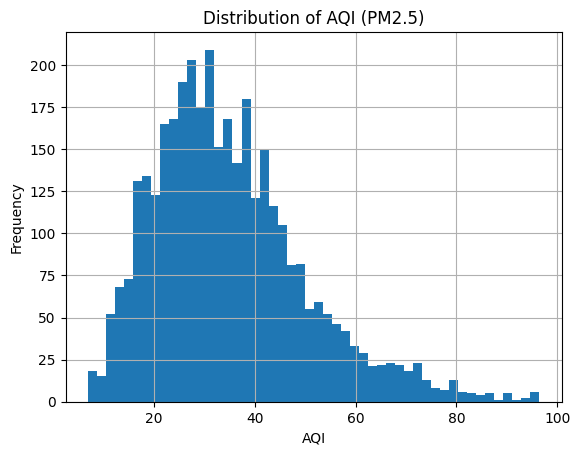

In [7]:
import matplotlib.pyplot as plt

eng_df["aqi_pm25"].hist(bins=50)
plt.title("Distribution of AQI (PM2.5)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [8]:
#Observation:
#AQI values are moderately right-skewed, with most values between 25–45.
#Few high outliers indicate occasional pollution spikes.

### Temporal Pattern Analysis
**Hourly Pattern **

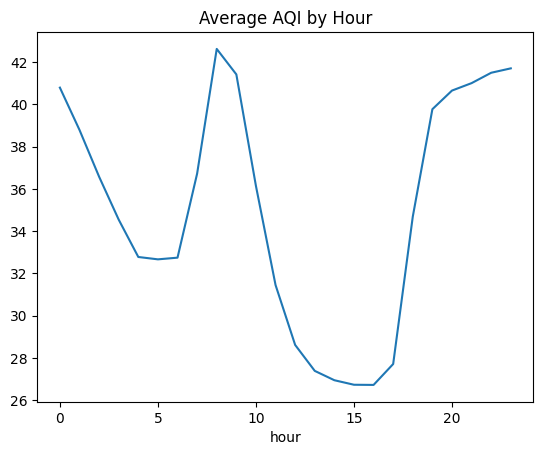

In [9]:
eng_df.groupby("hour")["aqi_pm25"].mean().plot()
plt.title("Average AQI by Hour")
plt.show()

In [10]:
#Observation:
#AQI decreases during mid-day and increases during late night.
#This reflects atmospheric dispersion behavior.

**Monthly Pattern**

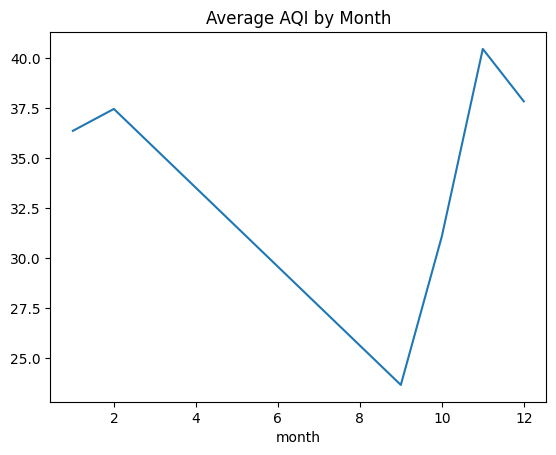

In [11]:
eng_df.groupby("month")["aqi_pm25"].mean().plot()
plt.title("Average AQI by Month")
plt.show()

In [12]:
#Observation:
#Preliminary seasonal variation observed within the 5-month window.
#Higher AQI levels seen during late-year months.

### Stationarity Discussion

Time-series forecasting models typically assume some degree of stationarity, meaning that the statistical properties of the series (mean and variance) remain relatively stable over time. The observed AQI series demonstrates temporal dependence and short-term fluctuations, as evidenced by hourly and monthly patterns. While the dataset spans only five months, minor seasonal trends are observable. The incorporation of lag features and rolling statistics helps capture temporal dynamics and partially stabilize the series. Although formal stationarity tests such as the Augmented Dickey-Fuller (ADF) test were not conducted in this exploratory phase, the modeling framework relies on supervised machine learning rather than classical ARIMA assumptions, reducing strict stationarity requirements.

**Correlation Analysis**

In [13]:
numeric_df = eng_df.select_dtypes(include=["number"])

numeric_df.corr()["target_h1"].sort_values(ascending=False)

target_h1           1.000000
pm2_5               0.545413
aqi_pm25            0.545413
target_h2           0.537744
lag_1               0.508671
roll_mean_6         0.447219
nitrogen_dioxide    0.429490
roll_mean_12        0.390816
target_h3           0.383115
carbon_monoxide     0.380345
lag_3               0.376495
pm10                0.285157
lag_6               0.245388
sulphur_dioxide     0.176767
month               0.020807
hour                0.006760
day                -0.014925
ozone              -0.260491
Name: target_h1, dtype: float64

In [14]:
#Key Findings:

#- lag_1 and rolling mean features show strong correlation.
#- Nitrogen dioxide and carbon monoxide moderately correlate.
#- Ozone shows negative association.
#- Pure time features show weak linear correlation.

**Heatmap**

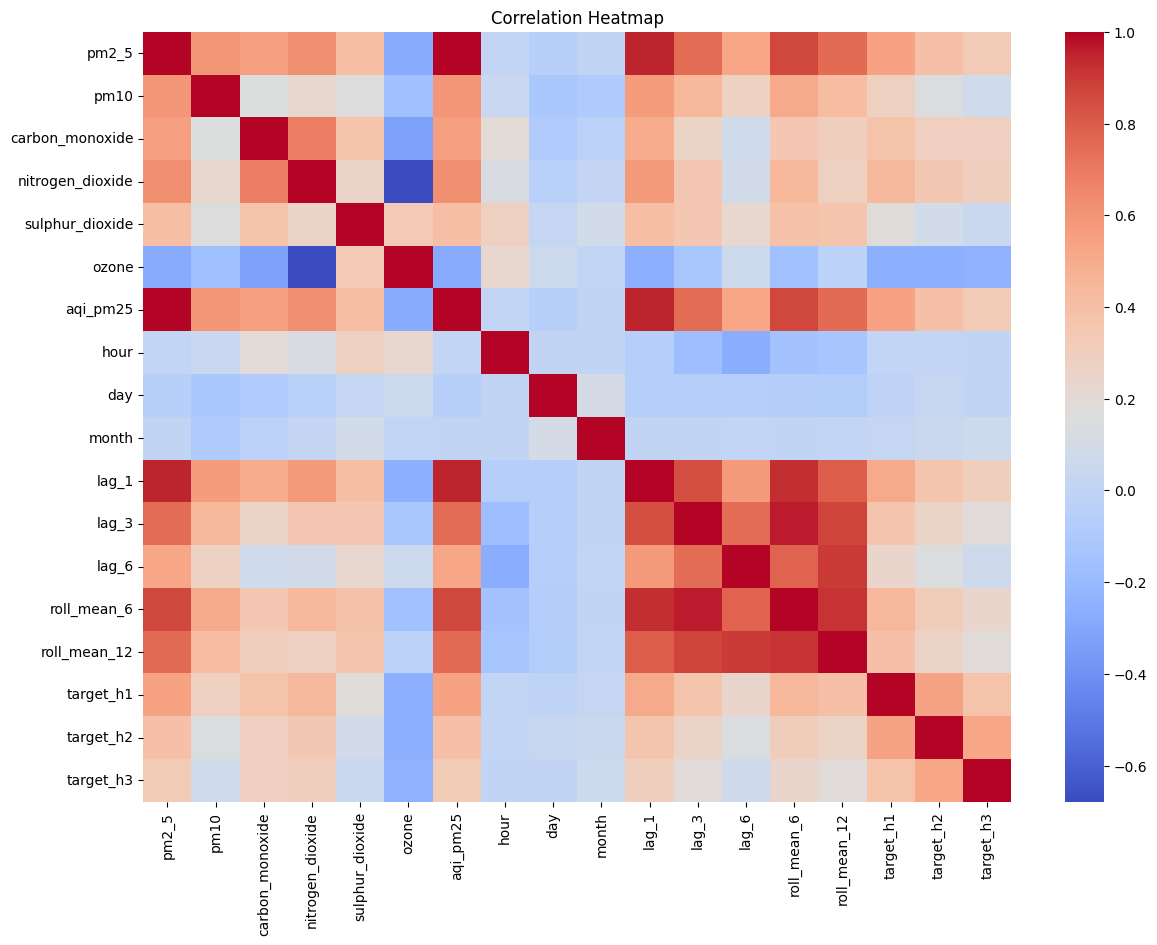

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = eng_df.select_dtypes(include=["number"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Multicollinearity Analysis

The correlation heatmap reveals strong positive correlations among lag features (lag_1, lag_3, lag_6) and rolling statistics (roll_mean_6, roll_mean_12), as these variables are derived from the same underlying PM2.5 time series. This indicates the presence of multicollinearity among engineered temporal predictors. In traditional linear regression models, multicollinearity may lead to unstable coefficient estimates and inflated variance. However, tree-based ensemble models such as Random Forest and Gradient Boosting are less sensitive to correlated predictors, making this issue manageable for the selected modeling approach.

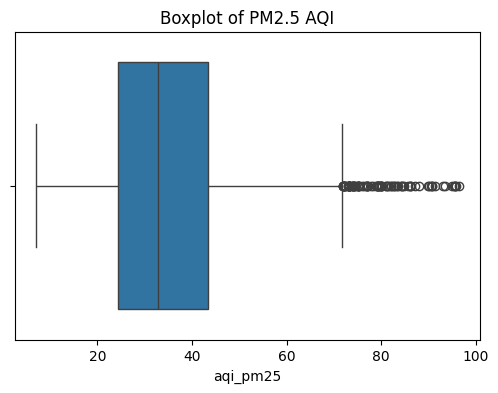

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=eng_df["aqi_pm25"])
plt.title("Boxplot of PM2.5 AQI")
plt.show()

**The boxplot confirms the presence of extreme upper-tail observations, consistent with episodic pollution events.**

In [17]:
numeric_df.corr()["target_h1"].sort_values(ascending=False)

target_h1           1.000000
pm2_5               0.545413
aqi_pm25            0.545413
target_h2           0.537744
lag_1               0.508671
roll_mean_6         0.447219
nitrogen_dioxide    0.429490
roll_mean_12        0.390816
target_h3           0.383115
carbon_monoxide     0.380345
lag_3               0.376495
pm10                0.285157
lag_6               0.245388
sulphur_dioxide     0.176767
month               0.020807
hour                0.006760
day                -0.014925
ozone              -0.260491
Name: target_h1, dtype: float64

 **Target Distribution Analysis**

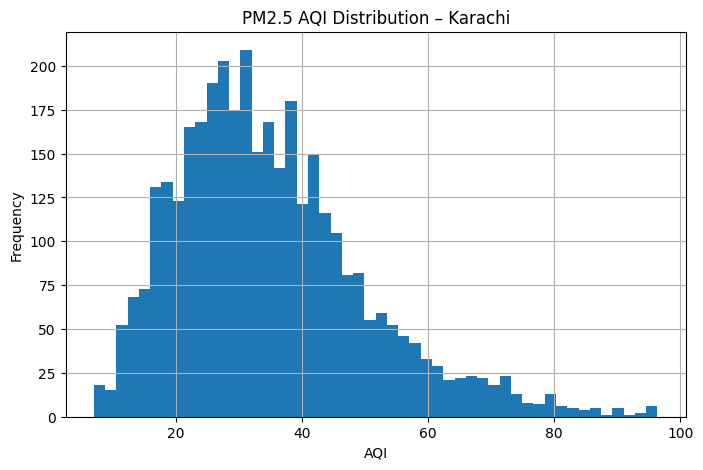

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(eng_df["aqi_pm25"], bins=50)

plt.title("PM2.5 AQI Distribution – Karachi")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

AQI values exhibit moderate right skewness.

Majority of observations lie between 25–45.

Occasional extreme values indicate pollution spikes.

This skewness suggests non-normal distribution, supporting the choice of tree-based models over purely linear approaches.

**# Weather–Pollutant Relationship Analysis**

**Scatter Plot: Nitrogen Dioxide vs AQI**

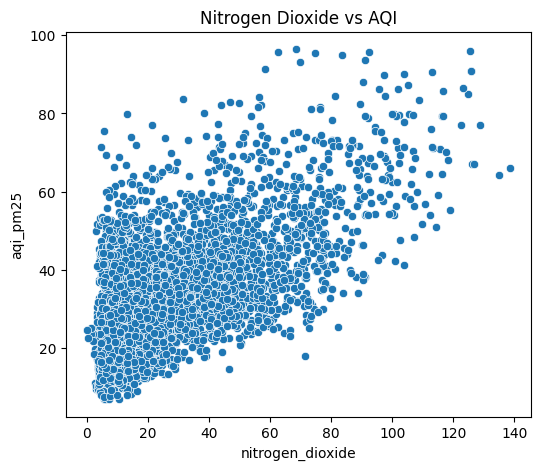

In [19]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="nitrogen_dioxide", y="aqi_pm25", data=eng_df)
plt.title("Nitrogen Dioxide vs AQI")
plt.show()

**Scatter Plot: Ozone vs AQI**

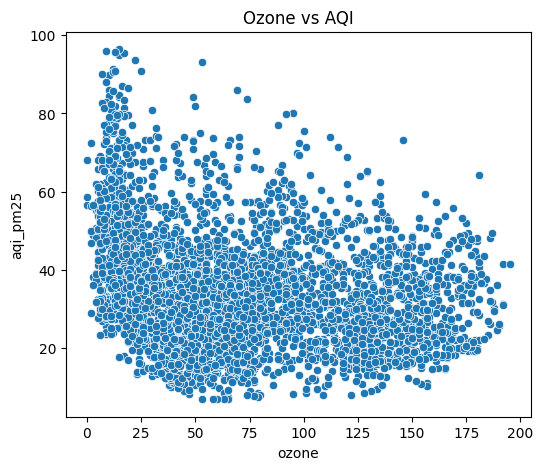

In [20]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="ozone", y="aqi_pm25", data=eng_df)
plt.title("Ozone vs AQI")
plt.show()

The scatter plot between nitrogen dioxide and AQI reveals a positive monotonic trend, supporting its moderate correlation (r ≈ 0.43). Conversely, ozone demonstrates a negative association, suggesting atmospheric chemical interactions that reduce particulate concentration under higher ozone levels.

# **Final EDA Summary**

The exploratory analysis confirms:

AQI exhibits strong temporal dependence.

Lag and rolling features provide strongest predictive signal.

Secondary pollutants moderately influence AQI levels.

Ozone shows inverse association with particulate concentration.

Time features alone have weak linear influence but support nonlinear modeling.

Multicollinearity exists among temporal features but is manageable under tree-based algorithms.

The dataset is suitable for multi-horizon forecasting using ensemble machine learning models. Overall, the exploratory analysis validates the engineered feature set and confirms the suitability of supervised ensemble learning methods for multi-horizon AQI forecasting in Karachi. The dataset demonstrates sufficient temporal structure, pollutant influence, and predictive signal strength to support robust forecasting model development.

